# Homework 5: Neural Networks for Recognition

#### **For each question please refer to the handout for more details.**

Programming questions begin at **Q2**. **Remember to run all cells** and save the notebook to your local machine as a pdf for gradescope submission.


# Collaborators
**List your collaborators for all questions here**:


---

# Q1 Theory


## Q1.1 (3 points)


Softmax is defined as below, for each index $i$ in a vector $x \in \mathbb{R}^d$.
$$ softmax(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}} $$
Prove that softmax is invariant to translation, that is
$$ softmax(x) = softmax(x + c) \quad \forall c \in \mathbb{R}.$$    
Often we use $c = -\max x_i$. Why is that a good idea? (Tip: consider the range of values that numerator will have with $c=0$ and $c = -\max x_i$)

---

YOUR ANSWER HERE...

$$
softmax(x+c) = \frac{e^{x_i + c}}{\sum_j e^{x_j + c}} = \frac{e^{c}e^{x_i}}{e^{c}\sum_j e^{x_j}} 
$$

The $e^{c}$ cancels out in the numerator and denominator, to get:
$$
\frac{e^{x_i}}{\sum_j e^{x_j}} = softmax(x)
$$

$c = -\max x_i$ is a good idea for numerical stability. The exponents become $x_i - \max x_i$, which range from $-\infty$ to $0$. This means the exponential values $e^{x_i - \max x_i}$ are bounded in $(0, 1]$, preventing overflow that would occur with large positive exponents.

---

## Q1.2

Softmax can be written as a three-step process, with $s_i = e^{x_i}$, $S = \sum s_i$ and $softmax(x)_i = \frac{1}{S} s_i$.

### Q1.2.1 (1 point)

As $x \in \mathbb{R}^d$, what are the properties of $softmax(x)$, namely what is the range of each element? What is the sum over all elements?

---

YOUR ANSWER HERE...

Each element $softmax(x)_i$ has range $(0, 1)$ (strictly between 0 and 1, since $s_i = e^{x_i} > 0$ and $S = \sum_j s_j > s_i$ for $d > 1$).

The sum over all elements is:
$$\sum_i softmax(x)_i = \sum_i \frac{s_i}{S} = \frac{1}{S}\sum_i s_i = \frac{S}{S} = 1$$

Therefore, softmax produces a probability distribution.

---

### Q1.2.2 (1 point)

One could say that "softmax takes an arbitrary real valued vector $x$ and turns it into a $\rule{3cm}{0.1mm}$.

---

YOUR ANSWER HERE...

Probability distribution

---

### Q1.2.3 (1 point)

Now explain the role of each step in the multi-step process.

---

YOUR ANSWER HERE...

Step 1: $s_i$ makes values positive via exponential

Step 2: $S$ computes the normalization constant

Step 3: $\frac{1}{S}$ normalizes to sum to 1

---

## Q1.3 (3 points)

Show that multi-layer neural networks without a non-linear activation function are equivalent to linear regression.




---

YOUR ANSWER HERE...

Consider a multi-layer network with $L$ layers, where layer $\ell$ computes:
$$h^{(\ell)} = W^{(\ell)} h^{(\ell-1)} + b^{(\ell)}$$

with input $h^{(0)} = x$.

Without non-linear activations, the output after $L$ layers is:
$$
\begin{align}
h^{(L)} &= W^{(L)}(W^{(L-1)}(\cdots W^{(1)}x + b^{(1)} \cdots) + b^{(L-1)}) + b^{(L)}\\
&= W^{(L)}W^{(L-1)}\cdots W^{(1)}x + \text{(combination of biases)}\\
&= \tilde{W}x + \tilde{b}
\end{align}
$$

where $\tilde{W} = W^{(L)}W^{(L-1)}\cdots W^{(1)}$ and $\tilde{b}$ is the accumulated bias term.

This is exactly linear regression: $y = \tilde{W}x + \tilde{b}$.

Therefore, stacking multiple linear layers without non-linearities is equivalent to a single linear layer, which is just linear regression.

---

## Q1.4 (3 points)

Given the sigmoid activation function $\sigma(x) = \frac{1}{1+e^{-x}}$, derive the gradient of the sigmoid function and show that it can be written as a function of $\sigma(x)$ (without having access to $x$ directly).

---

YOUR ANSWER HERE...


$$
\frac{d\sigma(x)}{dx} = \frac{d((1+e^{-x})^{-1})}{dx} = -(1+e^{-x})^{-2}(-e^{-x}) = e^{-x}(1+e^{-x})^{-2} = \frac{e^{-x}}{(1+e^{-x})^2} 
$$

$$
= (\frac{1}{(1+e^{-x})})(\frac{e^{-x}}{(1+e^{-x})})  = \sigma(x) (\frac{ (1 + e^{-x}) - 1}{(1+e^{-x})}) = \sigma(x) (1 - \frac{1}{1+e^{-x}})
$$

$$
= \sigma(x)(1 - \sigma(x)) 
$$

---

## Q1.5 (12 points)

Given $y = Wx + b$ (or $y_i = \sum_{j=1}^d  x_{j} W_{ij} + b_i$), and the gradient of some loss $J$ (a scalar) with respect to $y$, show how to get the gradients $\frac{\partial J}{\partial W}$, $\frac{\partial J}{\partial x}$ and $\frac{\partial J}{\partial b}$. Be sure to do the derivatives with scalars and re-form the matrix form afterwards. Here are some notional suggestions.
$$ x \in \mathbb{R}^{d \times 1} \quad y \in \mathbb{R}^{k \times 1} \quad W \in \mathbb{R}^{k \times d} \quad b \in \mathbb{R}^{k \times 1} \quad \frac{\partial J}{\partial y} = \delta \in \mathbb{R}^{k \times 1} $$

---

YOUR ANSWER HERE...

Starting with the scalar form: $y_i = \sum_{j=1}^d x_j W_{ij} + b_i$


$$
\frac{\partial J}{\partial W} = \frac{\partial J}{\partial y} \frac{\partial y}{\partial W}
$$

Where 
$$
\frac{\partial y}{\partial W} = x
$$
So,
$$
\frac{\partial J}{\partial W} = \delta x^T
$$

---

$$
\frac{\partial J}{\partial x} = \frac{\partial J}{\partial y} \frac{\partial y}{\partial x}
$$
Where 
$$
\frac{\partial y}{\partial x} = W
$$
So,
$$
\frac{\partial J}{\partial x} = W^T \delta
$$

---

$$
\frac{\partial J}{\partial b} = \frac{\partial J}{\partial y} \frac{\partial y}{\partial b}
$$
Where 
$$
\frac{\partial y}{\partial b} = 1
$$
So,
$$
\frac{\partial J}{\partial b} = \delta
$$

---

## Q1.6
When the neural network applies the elementwise activation function (such as sigmoid), the gradient of the activation function scales the backpropogation update. This is directly from the chain rule, $\frac{d}{d x} f(g(x)) = f'(g(x)) g'(x)$.

### Q1.6.1 (1 point)

Consider the sigmoid activation function for deep neural networks. Why might it lead to a "vanishing gradient" problem if it is used for many layers (consider plotting the gradient you derived in Q1.4)?

---

YOUR ANSWER HERE...

$\sigma(x) = \frac{1}{1+e^{-x}}$. It was found in Q1.4, 
the gradient of sigmoid is $\sigma'(x) = \sigma(x)(1-\sigma(x))$, which has a maximum value of 0.25. 
The max value of 0.25 happens when $\sigma(0) = 0.5$ and $\sigma'(0) = 0.5(1-0.5) = 0.25$

During backpropagation through many layers, these gradients multiply together via the chain rule. Since each gradient is at most 0.25, the product $(0.25)^n$ shrinks exponentially with depth $n$, causing gradients in early layers to vanish.

---

### Q1.6.2 (1 point)
Often it is replaced with $\tanh(x) = \frac{1-e^{-2x}}{1+e^{-2x}}$. What are the output ranges of both $\tanh$ and sigmoid? Why might we prefer $\tanh$?

---

YOUR ANSWER HERE...

The output range of sigmoid is 0 to +1.

The output range of tanh is -1 to +1.

We might prefer tanh because it is zero-centered (outputs range from -1 to 1), which helps with more balanced gradient updates during training compared to sigmoid's always-positive outputs (0 to 1).

---

### Q1.6.3 (1 point)
Why does $\tanh(x)$ have less of a vanishing gradient problem? (plotting the gradients helps! for reference: $\tanh'(x) = 1 - \tanh(x)^2$)

---

YOUR ANSWER HERE...

$tanh'(x)$ has a max value of 1, when $x=0$ and $tanh(0) = 0$, so $tanh'(0) = 1-tanh(0)^2 = 1 - 0^2 = 1$. 

This is 4 times larger than the max value of $\sigma'(x)$ of 0.25. Higher value reduces the effects of vanishing gradient, for example $1^n$ will remain 1.


---

### Q1.6.4 (1 point)
$\tanh$ is a scaled and shifted version of the sigmoid. Show how $\tanh(x)$ can be written in terms of $\sigma(x)$.

---

YOUR ANSWER HERE...

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

and
$$\sigma(2x) = \frac{1}{1+e^{-2x}}$$
and
$$1-\sigma(2x) = \frac{1+e^{-2x}}{1+e^{-2x}} - \frac{1}{1+e^{-2x}} = \frac{1+e^{-2x} - 1}{1+e^{-2x}} = \frac{e^{-2x}}{1+e^{-2x}}$$


$$
\tanh(x) = \frac{1-e^{-2x}}{1+e^{-2x}}

= \frac{1}{1+e^{-2x}} - \frac{e^{-2x}}{1+e^{-2x}}
$$

$$
= \sigma(2x) - (1 - \sigma(2x))
= 2\sigma(2x) - 1
$$

This shows tanh is indeed a scaled (by factor of 2) and shifted (by -1) version of sigmoid!

---


# Q2 Implement a Fully Connected Network

Run the following code to import the modules you'll need. When implementing the functions in Q2, make sure you run the test code (provided after Q2.3) along the way to check if your implemented functions work as expected.

In [1]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.patches
from mpl_toolkits.axes_grid1 import ImageGrid

import skimage
import skimage.measure
import skimage.color
import skimage.restoration
import skimage.filters
import skimage.morphology
import skimage.segmentation

## Q2.1 Network Initialization

### Q2.1.1 (3 points)

Why is it not a good idea to initialize a network with all zeros? If you imagine that every layer has weights and biases, what can a zero-initialized network output be after training?

---

YOUR ANSWER HERE...

Initializing all weights to zero causes a **symmetry problem**. All neurons in a layer will compute identical outputs and receive identical gradients during backpropagation. This means all weights update identically, so neurons never learn different features - they remain redundant copies throughout training.

After training, a zero-initialized network would essentially behave like a network with only one neuron per layer, severely limiting its representational capacity. The network cannot learn meaningful patterns.

(Note: Biases can be initialized to zero without issues, but weights must be randomly initialized to break symmetry.)

---

### Q2.1.2 (3 points)

Implement the initialize_weights() function to initialize the weights for a single layer with Xavier initialization, where $Var[w] = \frac{2}{n_{in}+ n_{out}}$ where $n$ is the dimensionality of the vectors and you use a uniform distribution to sample random numbers (see eq 16 in [Glorot et al]).

---

$Var[w] = \frac{(b-a)^2)}{12}$

Sub in a uniform distribution centered about 0, between $[-k,k]$ to get:

$Var[w] = \frac{(k--k)^2)}{12} = \frac{(2k)^{2})}{12} = \frac{(4k^2)}{12} = \frac{k^2}{3}$

Therefore,

$Var[w] = \frac{k^2}{3} = \frac{2}{n_{in}+ n_{out}}$

So, 

$k = \sqrt{\frac{6}{n_{in}+ n_{out}}}$


In [2]:
############################## Q 2.1.2 ##############################
def initialize_weights(in_size, out_size, params,name=''):
    """
    we will do XW + b, with the size of the input data array X being [number of examples, in_size]
    the weights W should be initialized as a 2D array
    the bias vector b should be initialized as a 1D array, not a 2D array with a singleton dimension
    the output of this layer should be in size [number of examples, out_size]
    """
    W, b = None, None

    ##########################
    ##### your code here #####


    # XW = (N, in_size) * (in_size, out_size) = (N, out_size)
    limit = np.sqrt(6/(in_size + out_size))
    W = np.random.uniform(-limit, limit, (in_size, out_size))
    b = np.zeros(out_size)


    ##########################

    params['W' + name] = W
    params['b' + name] = b

### Q2.1.3 (2 points)

Why do we scale the initialization depending on layer size (see Fig 6 in the [Glorot et al])?

---

YOUR ANSWER HERE...

The variance $\text{Var}[w] = \frac{2}{n_{in} + n_{out}}$ is dependent on the layer sizes $n_{in}$ and $n_{out}$ because as the layer size increases, the denominator increases proportionally. As a result, the range of the uniform distribution (and thus the weight values) decreases as the layer size increases.

This is necessary because when computing $y = Wx$, we sum over all $n_{in}$ inputs. With more inputs, we're adding more terms together, which naturally makes the output larger. By making each individual weight smaller (smaller variance), we compensate for having more terms in the sum, keeping the output variance stable across layers of different sizes. This prevents activations from exploding in large layers or vanishing in small layers.

---

## Q2.2 Forward Propagation

### Q2.2.1 (4 points)

Implement the sigmoid() function, which computes the elementwise sigmoid activation of entries in an input array. Then implement the forward() function which computes forward propagation for a single layer, namely $y = \sigma(X W + b)$.

In [3]:
############################## Q 2.2.1 ##############################
def sigmoid(x):
    """
    Implement an elementwise sigmoid activation function on the input x,
    where x is a numpy array of size [number of examples, number of output dimensions]
    """
    res = None

    ##########################
    ##### your code here #####
    res = 1 / (1 + np.exp(-x))

    ##########################


    return res

In [4]:
############################## Q 2.2.1 ##############################
def forward(X,params,name='',activation=sigmoid):
    """
    Do a forward pass for a single layer that computes the output: activation(XW + b)

    Keyword arguments:
    X -- input numpy array of size [number of examples, number of input dimensions]
    params -- a dictionary containing parameters, as how you initialized in Q 2.1.2
    name -- name of the layer
    activation -- the activation function (default is sigmoid)
    """
    # compute the output values before and after the activation function
    pre_act, post_act = None, None
    # get the layer parameters
    W = params['W' + name]
    b = params['b' + name]


    ##########################
    ##### your code here #####
    pre_act = X @ W + b
    post_act = activation(pre_act)
    ##########################


    # store the pre-activation and post-activation values
    # these will be important in backpropagation
    params['cache_' + name] = (X, pre_act, post_act)

    return post_act

### Q2.2.2 (3 points)

Implement the softmax() function. Be sure to use the numerical stability trick you derived in Q1.1 softmax.

In [5]:
############################## Q 2.2.2  ##############################
def softmax(x):
    """
    x is a numpy array of size [number of examples, number of classes]
    softmax should be done for each row
    """
    res = None

    ##########################
    ##### your code here #####
    c = -np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x + c)
    res = exp_x / np.sum(exp_x, axis=1, keepdims=True)
    ##########################

    return res

### Q2.2.3 (3 points)

Implement the compute_loss_and_acc() function to compute the accuracy given a set of labels, along with the scalar loss across the data. The loss function generally used for classification is the cross-entropy loss.

$$L_{f}(\mathbf{D}) = - \sum_{(x, y)\in \mathbf{D}}y \cdot \log(f(x))$$

Here $\mathbf{D}$ is the full training dataset of $N$ data samples $x$ (which are $D \times 1$ vectors, $D$ is the dimensionality of data) and labels $y$ (which are $C\times 1$ one-hot vectors, $C$ is the number of classes), and $f:\mathbb{R}^D\to[0,1]^C$ is the classifier which outputs the probabilities for the classes.
The $\log$ is the natural $\log$.

In [6]:
############################## Q 2.2.3 ##############################
def compute_loss_and_acc(y, probs):
    """
    compute total loss and accuracy

    Keyword arguments:
    y -- the labels, which is a numpy array of size [number of examples, number of classes]
    probs -- the probabilities output by the classifier, i.e. f(x), which is a numpy array of size [number of examples, number of classes]
    """
    loss, acc = None, None

    ##########################
    ##### your code here #####

    loss = -np.sum(y * np.log(probs))
    acc = np.sum(np.argmax(probs, axis=1) == np.argmax(y, axis=1)) / y.shape[0]
    ##########################


    return loss, acc

## Q2.3 Backwards Propagation

### Q2.3 (7 points)

Implement the backwards() function to compute backpropagation for a single layer, given the original weights, the appropriate intermediate results, and the gradient with respect to the loss. You should return the gradient with respect to the inputs (grad_X) so that it can be used in the backpropagation for the previous layer. As a size check, your gradients should have the same dimensions as the original objects.


In [7]:
############################## Q 2.3 ##############################
def sigmoid_deriv(post_act):
    """
    we give this to you, because you proved it in Q1.4
    it's a function of the post-activation values (post_act)
    """
    res = post_act*(1.0-post_act)
    return res

def backwards(delta,params,name='',activation_deriv=sigmoid_deriv):
    """
    Do a backpropagation pass for a single layer.

    Keyword arguments:
    delta -- gradients of the loss with respect to the outputs (errors to back propagate), in [number of examples, number of output dimensions]
    params -- a dictionary containing parameters, as how you initialized in Q 2.1.2
    name -- name of the layer
    activation_deriv -- the derivative of the activation function
    """
    grad_X, grad_W, grad_b = None, None, None
    # everything you may need for this layer
    W = params['W' + name]
    b = params['b' + name]
    X, pre_act, post_act = params['cache_' + name]

    # by the chain rule, do the derivative through activation first
    # (don't forget activation_deriv is a function of post_act)
    # then compute the gradients w.r.t W, b, and X
    ##########################
    ##### your code here #####
    # Chain rule: gradient through activation function
    grad_pre_act = delta * activation_deriv(post_act)

    # Gradients w.r.t. parameters and input
    grad_W = X.T @ grad_pre_act
    grad_b = np.sum(grad_pre_act, axis=0)
    grad_X = grad_pre_act @ W.T
    ##########################


    # store the gradients
    params['grad_W' + name] = grad_W
    params['grad_b' + name] = grad_b
    return grad_X

Make sure you run below test code along the way to check if your implemented functions work as expected.

In [8]:
def linear(x):
    # Define a linear activation, which can be used to construct a "no activation" layer
    return x

def linear_deriv(post_act):
    return np.ones_like(post_act)

In [9]:
# test code
# generate some fake data
# feel free to plot it in 2D, what do you think these 4 classes are?
g0 = np.random.multivariate_normal([3.6,40],[[0.05,0],[0,10]],10)
g1 = np.random.multivariate_normal([3.9,10],[[0.01,0],[0,5]],10)
g2 = np.random.multivariate_normal([3.4,30],[[0.25,0],[0,5]],10)
g3 = np.random.multivariate_normal([2.0,10],[[0.5,0],[0,10]],10)
x = np.vstack([g0,g1,g2,g3])

# we will do XW + B in the forward pass
# this implies that the data X is in [number of examples, number of input dimensions]

# create labels
y_idx = np.array([0 for _ in range(10)] + [1 for _ in range(10)] + [2 for _ in range(10)] + [3 for _ in range(10)])
# turn to one-hot encoding, this implies that the labels y is in [number of examples, number of classes]
y = np.zeros((y_idx.shape[0],y_idx.max()+1))
y[np.arange(y_idx.shape[0]),y_idx] = 1
print("data shape: {} labels shape: {}".format(x.shape, y.shape))

# parameters in a dictionary
params = {}

# Q 2.1.2
# we will build a two-layer neural network
# first, initialize the weights and biases for the two layers
# the first layer, in_size = 2 (the dimension of the input data), out_size = 25 (number of neurons)
initialize_weights(2,25,params,'layer1')
# the output layer, in_size = 25 (number of neurons), out_size = 4 (number of classes)
initialize_weights(25,4,params,'output')
assert(params['Wlayer1'].shape == (2,25))
assert(params['blayer1'].shape == (25,))
assert(params['Woutput'].shape == (25,4))
assert(params['boutput'].shape == (4,))

# with Xavier initialization
# expect the means close to 0, variances in range [0.05 to 0.12]
print("Q 2.1.2: {}, {:.2f}".format(params['blayer1'].mean(),params['Wlayer1'].std()**2))
print("Q 2.1.2: {}, {:.2f}".format(params['boutput'].mean(),params['Woutput'].std()**2))

# Q 2.2.1
# implement sigmoid
# there might be an overflow warning due to exp(1000)
test = sigmoid(np.array([-1000,1000]))
print('Q 2.2.1: sigmoid outputs should be zero and one\t',test.min(),test.max())
# a forward pass on the first layer, with sigmoid activation
h1 = forward(x,params,'layer1',sigmoid)
assert(h1.shape == (40, 25))

# Q 2.2.2
# implement softmax
# a forward pass on the second layer (the output layer), with softmax so that the outputs are class probabilities
probs = forward(h1,params,'output',softmax)
# make sure you understand these values!
# should be positive, 1 (or very close to 1), 1 (or very close to 1)
print('Q 2.2.2:',probs.min(),min(probs.sum(1)),max(probs.sum(1)))
assert(probs.shape == (40,4))

# Q 2.2.3
# implement compute_loss_and_acc
loss, acc = compute_loss_and_acc(y, probs)
# should be around -np.log(0.25)*40 [~55] or higher, and 0.25
# if it is not, check softmax!
print("Q 2.2.3 loss: {}, acc:{:.2f}".format(loss,acc))

# Q 2.3
# here we cheat for you, you can use it in the training loop in Q2.4
# the derivative of cross-entropy(softmax(x)) is probs - 1[correct actions]
delta1 = probs - y

# backpropagation for the output layer
# we already did derivative through softmax when computing delta1 as above
# so we pass in a linear_deriv, which is just a vector of ones to make this a no-op
delta2 = backwards(delta1,params,'output',linear_deriv)
# backpropagation for the first layer
backwards(delta2,params,'layer1',sigmoid_deriv)

# the sizes of W and b should match the sizes of their gradients
for k,v in sorted(list(params.items())):
    if 'grad' in k:
        name = k.split('_')[1]
        # print the size of the gradient and the size of the parameter, the two sizes should be the same
        print('Q 2.3',name,v.shape, params[name].shape)

data shape: (40, 2) labels shape: (40, 4)
Q 2.1.2: 0.0, 0.08
Q 2.1.2: 0.0, 0.07
Q 2.2.1: sigmoid outputs should be zero and one	 0.0 1.0
Q 2.2.2: 0.12759405818820868 0.9999999999999998 1.0000000000000002
Q 2.2.3 loss: 56.49655491931465, acc:0.25
Q 2.3 Wlayer1 (2, 25) (2, 25)
Q 2.3 Woutput (25, 4) (25, 4)
Q 2.3 blayer1 (25,) (25,)
Q 2.3 boutput (4,) (4,)


/var/folders/9f/cx6nkp3s6nl5yc_5dgyd8z580000gn/T/ipykernel_13434/1143807612.py:11: RuntimeWarning: overflow encountered in exp
  res = 1 / (1 + np.exp(-x))


## Q2.4 Training Loop: Stochastic Gradient Descent

### Q2.4 (5 points)
Implement the get_random_batches() function that takes the entire dataset (x and y) as input and splits it into random batches. Write a training loop that iterates over the batches, does forward and backward propagation, and applies a gradient update. The provided code samples batch only once, but it is also common to sample new random batches at each epoch. You may optionally try both strategies and note any difference in performance.

In [10]:
############################## Q 2.4 ##############################
def get_random_batches(x,y,batch_size):
    """
    split x (data) and y (labels) into random batches
    return a list of [(batch1_x,batch1_y)...]
    """
    batches = []

    ##########################
    ##### your code here #####

    # Shuffle the data
    indices = np.random.permutation(len(x))
    x = x[indices]
    y = y[indices]

    # Split into batches
    for i in range(0, len(x), batch_size):
        batch_x = x[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        batches.append((batch_x, batch_y))
    
    ##########################


    return batches

In [11]:
# Q 2.4
batches = get_random_batches(x,y,5)
batch_num = len(batches)
# print batch sizes
print([_[0].shape[0] for _ in batches])
print(batch_num)

[5, 5, 5, 5, 5, 5, 5, 5]
8


In [12]:
############################## Q 2.4 ##############################
# WRITE A TRAINING LOOP HERE
max_iters = 500
learning_rate = 1e-3
# with default settings, you should get loss <= 35 and accuracy >= 75%
for itr in range(max_iters):
    total_loss = 0
    total_acc = 0
    
    for xb, yb in batches:
        ##########################
        ##### your code here #####
        ##########################
        # forward
        h1 = forward(xb, params, 'layer1', sigmoid)
        probs = forward(h1, params, 'output', softmax)
        loss, acc = compute_loss_and_acc(yb, probs)

        # accumulate loss and accuracy
        total_loss += loss
        total_acc += acc

        # backward
        delta1 = probs - yb
        delta2 = backwards(delta1, params, 'output', linear_deriv)
        backwards(delta2, params, 'layer1', sigmoid_deriv)

        # apply gradient to update the parameters
        params['Wlayer1'] -= learning_rate * params['grad_Wlayer1']
        params['blayer1'] -= learning_rate * params['grad_blayer1']
        params['Woutput'] -= learning_rate * params['grad_Woutput']
        params['boutput'] -= learning_rate * params['grad_boutput']

    # compute average - divide by total number of examples
    avg_acc = total_acc / len(batches)

    if itr % 100 == 0:
        print("itr: {:02d} \t loss: {:.2f} \t acc : {:.2f}".format(itr, total_loss, avg_acc))

itr: 00 	 loss: 56.47 	 acc : 0.25
itr: 100 	 loss: 39.75 	 acc : 0.75
itr: 200 	 loss: 33.64 	 acc : 0.75
itr: 300 	 loss: 29.77 	 acc : 0.80
itr: 400 	 loss: 27.38 	 acc : 0.80


# Q3 Training Models

Run below code to download and put the unzipped data in '/content/data' folder.

We have provided you three data .mat files to use for this section.
The training data in nist36_train.mat contains samples for each of the 26 upper-case letters of the alphabet and the 10 digits. This is the set you should use for training your network.
The cross-validation set in nist36_valid.mat contains samples from each class, and should be used in the training loop to see how the network is performing on data that it is not training on. This will help to spot overfitting.
Finally, the test data in nist36_test.mat contains testing data, and should be used for the final evaluation of your best model to see how well it will generalize to new unseen data.

In [13]:
if not os.path.exists('data'):
  os.mkdir('data')
  !wget http://www.cs.cmu.edu/~lkeselma/16720a_data/data.zip -O data/data.zip
  !unzip "data/data.zip" -d "data"
  os.system("rm data/data.zip")

In [14]:
ls data

nist26_model_60iters.mat* nist26_valid.mat*         nist36_valid.mat*
nist26_test.mat*          nist36_test.mat*
nist26_train.mat*         nist36_train.mat*


## Q3.1 (5 points)

Train a network from scratch. Use a single hidden layer with 64 hidden units, and train for at least 50 epochs. The script will generate two plots:
    
(1) the accuracy on both the training and validation set over the epochs, and
    
(2) the cross-entropy loss averaged over the data.
    
Tune the batch size and learning rate for accuracy on the validation set of at least 75\%. Hint: Use fixed random seeds to improve reproducibility.

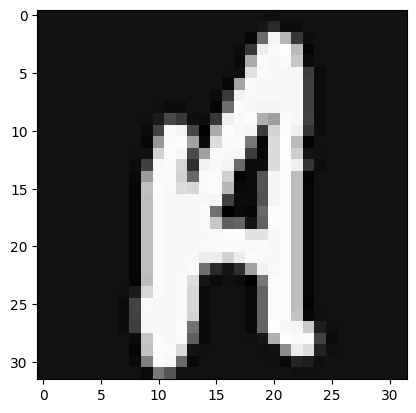

In [15]:
train_data = scipy.io.loadmat('data/nist36_train.mat')
valid_data = scipy.io.loadmat('data/nist36_valid.mat')
test_data = scipy.io.loadmat('data/nist36_test.mat')

train_x, train_y = train_data['train_data'], train_data['train_labels']
valid_x, valid_y = valid_data['valid_data'], valid_data['valid_labels']
test_x, test_y = test_data['test_data'], test_data['test_labels']

if True: # view the data
    for crop in train_x:
        plt.imshow(crop.reshape(32,32).T, cmap="Greys")
        plt.show()
        break

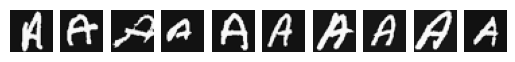

In [16]:
# Show a few data image and their labels
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(train_x[i].reshape(32,32).T, cmap="Greys")
    plt.axis('off')
plt.show()


In [17]:
############################## Q 3.1 ##############################
max_iters = 50
# pick a batch size, learning rate
batch_size = 32
learning_rate = 1e-3
hidden_size = 64
##########################
##### your code here #####
# Fix the random seed
np.random.seed(42)
##########################


batches = get_random_batches(train_x,train_y,batch_size)
batch_num = len(batches)

params = {}

# initialize layers
initialize_weights(train_x.shape[1], hidden_size, params, "layer1")
initialize_weights(hidden_size, train_y.shape[1], params, "output")
layer1_W_initial = np.copy(params["Wlayer1"]) # copy for Q3.3

train_loss = []
valid_loss = []
train_acc = []
valid_acc = []
for itr in range(max_iters):
    # record training and validation loss and accuracy for plotting
    h1 = forward(train_x,params,'layer1',sigmoid)
    probs = forward(h1,params,'output',softmax)
    loss, acc = compute_loss_and_acc(train_y, probs)
    train_loss.append(loss/train_x.shape[0])
    train_acc.append(acc)

    h1 = forward(valid_x,params,'layer1',sigmoid)
    probs = forward(h1,params,'output',softmax)
    loss, acc = compute_loss_and_acc(valid_y, probs)
    valid_loss.append(loss/valid_x.shape[0])
    valid_acc.append(acc)

    total_loss = 0
    avg_acc = 0
    for xb,yb in batches:
        # training loop can be exactly the same as q2!
        ##########################
        ##### your code here #####
        ##########################
        # forward
        h1 = forward(xb, params, 'layer1', sigmoid)
        probs = forward(h1, params, 'output', softmax)
        loss, acc = compute_loss_and_acc(yb, probs)

        # accumulate loss and accuracy
        total_loss += loss
        avg_acc += acc

        # backward
        delta1 = probs - yb
        delta2 = backwards(delta1, params, 'output', linear_deriv)
        backwards(delta2, params, 'layer1', sigmoid_deriv)

        # apply gradient to update the parameters
        params['Wlayer1'] -= learning_rate * params['grad_Wlayer1']
        params['blayer1'] -= learning_rate * params['grad_blayer1']
        params['Woutput'] -= learning_rate * params['grad_Woutput']
        params['boutput'] -= learning_rate * params['grad_boutput']

    # compute average - divide by total number of examples
    avg_acc = avg_acc / len(batches)

    if itr % 2 == 0:
        print("itr: {:02d}   loss: {:.2f}   acc: {:.2f}".format(itr,total_loss,avg_acc))

# record final training and validation accuracy and loss
h1 = forward(train_x,params,'layer1',sigmoid)
probs = forward(h1,params,'output',softmax)
loss, acc = compute_loss_and_acc(train_y, probs)
train_loss.append(loss/train_x.shape[0])
train_acc.append(acc)

h1 = forward(valid_x,params,'layer1',sigmoid)
probs = forward(h1,params,'output',softmax)
loss, acc = compute_loss_and_acc(valid_y, probs)
valid_loss.append(loss/valid_x.shape[0])
valid_acc.append(acc)

# report validation accuracy; aim for 75%
print('Validation accuracy: ', valid_acc[-1])

# compute and report test accuracy
h1 = forward(test_x,params,'layer1',sigmoid)
test_probs = forward(h1,params,'output',softmax)
_, test_acc = compute_loss_and_acc(test_y, test_probs)
print('Test accuracy: ', test_acc)

itr: 00   loss: 38089.48   acc: 0.08
itr: 02   loss: 32613.60   acc: 0.37
itr: 04   loss: 26496.65   acc: 0.50
itr: 06   loss: 21990.16   acc: 0.56
itr: 08   loss: 18990.68   acc: 0.60
itr: 10   loss: 16966.98   acc: 0.62
itr: 12   loss: 15540.45   acc: 0.64
itr: 14   loss: 14484.93   acc: 0.66
itr: 16   loss: 13668.65   acc: 0.68
itr: 18   loss: 13013.06   acc: 0.69
itr: 20   loss: 12469.71   acc: 0.70
itr: 22   loss: 12007.60   acc: 0.71
itr: 24   loss: 11606.24   acc: 0.72
itr: 26   loss: 11251.66   acc: 0.73
itr: 28   loss: 10934.01   acc: 0.73
itr: 30   loss: 10646.17   acc: 0.74
itr: 32   loss: 10382.84   acc: 0.75
itr: 34   loss: 10140.00   acc: 0.75
itr: 36   loss: 9914.50   acc: 0.76
itr: 38   loss: 9703.85   acc: 0.76
itr: 40   loss: 9506.08   acc: 0.77
itr: 42   loss: 9319.53   acc: 0.77
itr: 44   loss: 9142.88   acc: 0.78
itr: 46   loss: 8975.01   acc: 0.78
itr: 48   loss: 8814.99   acc: 0.78
Validation accuracy:  0.7372222222222222
Test accuracy:  0.7438888888888889


In [18]:
# save the final network
import pickle

saved_params = {k:v for k,v in params.items() if '_' not in k}
with open('q3_weights.pickle', 'wb') as handle:
  pickle.dump(saved_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

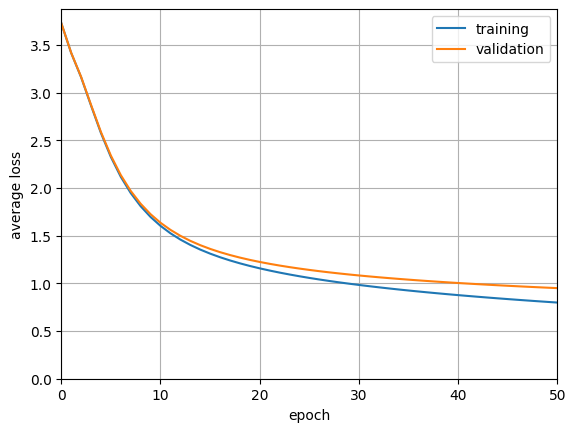

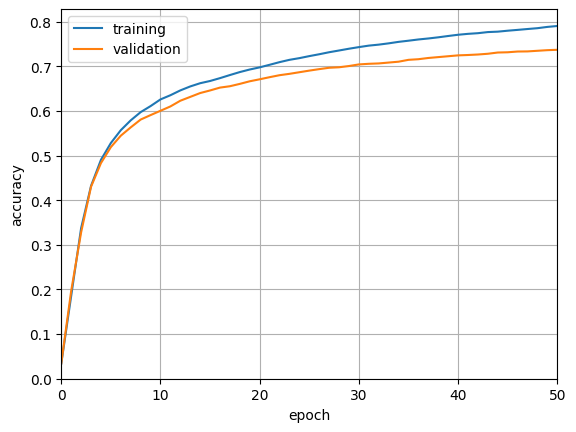

In [19]:
# plot loss curves
plt.plot(range(len(train_loss)), train_loss, label="training")
plt.plot(range(len(valid_loss)), valid_loss, label="validation")
plt.xlabel("epoch")
plt.ylabel("average loss")
plt.xlim(0, len(train_loss)-1)
plt.ylim(0, None)
plt.legend()
plt.grid()
plt.show()

# plot accuracy curves
plt.plot(range(len(train_acc)), train_acc, label="training")
plt.plot(range(len(valid_acc)), valid_acc, label="validation")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.xlim(0, len(train_acc)-1)
plt.ylim(0, None)
plt.legend()
plt.grid()
plt.show()

## Q3.2 (3 points)

The provided code will visualize the first layer weights as 64 32x32 images, both immediately after initialization and after full training. Generate both visualizations. Comment on the learned weights and compare them to the initialized weights. Do you notice any patterns?

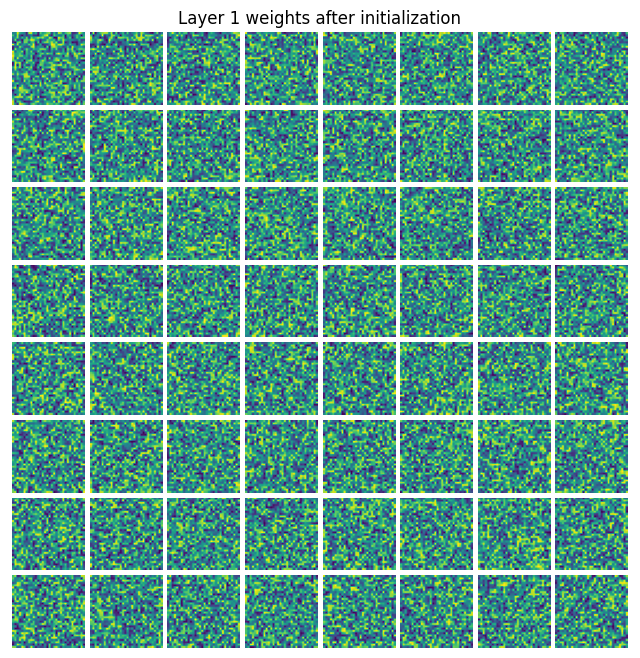

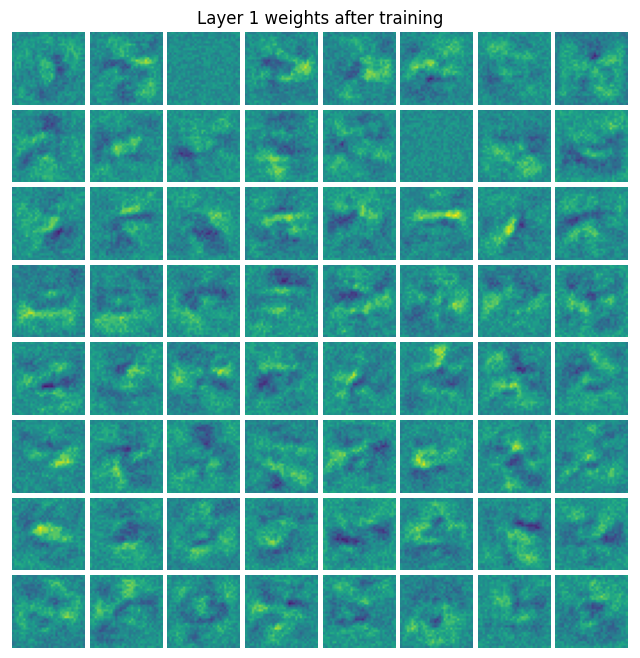

In [20]:
############################## Q 3.2 ##############################
# visualize weights
fig = plt.figure(figsize=(8,8))
plt.title("Layer 1 weights after initialization")
plt.axis("off")
grid = ImageGrid(fig, 111, nrows_ncols=(8, 8), axes_pad=0.05)
for i, ax in enumerate(grid):
    ax.imshow(layer1_W_initial[:,i].reshape((32, 32)).T)
    ax.set_axis_off()
plt.show()

v = np.max(np.abs(params['Wlayer1']))
fig = plt.figure(figsize=(8,8))
plt.title("Layer 1 weights after training")
plt.axis("off")
grid = ImageGrid(fig, 111, nrows_ncols=(8, 8), axes_pad=0.05)
for i, ax in enumerate(grid):
    ax.imshow(params['Wlayer1'][:,i].reshape((32, 32)).T, vmin=-v, vmax=v)
    ax.set_axis_off()
plt.show()

---

YOUR ANSWER HERE...

In "Layer 1 weights after initialization", the weights look like noise and has no real structure.


In "Layer 1 weights after training", the weights start forming shapes and are more cohesive patterns that form.

---

## Q3.3 (3 points)

Use the code in Q3.1 to train and generate accuracy and loss plots for each of these three networks:

(1) one with $10$ times your tuned learning rate,
    
(2) one with one-tenth your tuned learning rate, and

(3) one with your tuned learning rate.
    
Include total of six plots (two will be the same from Q3.1). Comment on how the learning rates affect the training, and report the final accuracy of the best network on the test set. Hint: Use fixed random seeds to improve reproducibility.

In [21]:
############################## Q 3.3 ##############################
##########################
##### your code here #####


def train_network(learning_rate):
    ############################## Q 3.1 ##############################
    max_iters = 50
    # pick a batch size, learning rate
    batch_size = 32
    hidden_size = 64
    ##########################
    ##### your code here #####
    # Fix the random seed
    np.random.seed(42)
    ##########################


    batches = get_random_batches(train_x,train_y,batch_size)
    batch_num = len(batches)

    params = {}

    # initialize layers
    initialize_weights(train_x.shape[1], hidden_size, params, "layer1")
    initialize_weights(hidden_size, train_y.shape[1], params, "output")
    layer1_W_initial = np.copy(params["Wlayer1"]) # copy for Q3.3

    train_loss = []
    valid_loss = []
    train_acc = []
    valid_acc = []
    for itr in range(max_iters):
        # record training and validation loss and accuracy for plotting
        h1 = forward(train_x,params,'layer1',sigmoid)
        probs = forward(h1,params,'output',softmax)
        loss, acc = compute_loss_and_acc(train_y, probs)
        train_loss.append(loss/train_x.shape[0])
        train_acc.append(acc)

        h1 = forward(valid_x,params,'layer1',sigmoid)
        probs = forward(h1,params,'output',softmax)
        loss, acc = compute_loss_and_acc(valid_y, probs)
        valid_loss.append(loss/valid_x.shape[0])
        valid_acc.append(acc)

        total_loss = 0
        avg_acc = 0
        for xb,yb in batches:
            # training loop can be exactly the same as q2!
            ##########################
            ##### your code here #####
            ##########################
            # forward
            h1 = forward(xb, params, 'layer1', sigmoid)
            probs = forward(h1, params, 'output', softmax)
            loss, acc = compute_loss_and_acc(yb, probs)

            # accumulate loss and accuracy
            total_loss += loss
            avg_acc += acc

            # backward
            delta1 = probs - yb
            delta2 = backwards(delta1, params, 'output', linear_deriv)
            backwards(delta2, params, 'layer1', sigmoid_deriv)

            # apply gradient to update the parameters
            params['Wlayer1'] -= learning_rate * params['grad_Wlayer1']
            params['blayer1'] -= learning_rate * params['grad_blayer1']
            params['Woutput'] -= learning_rate * params['grad_Woutput']
            params['boutput'] -= learning_rate * params['grad_boutput']

        # compute average - divide by total number of examples
        avg_acc = avg_acc / len(batches)

        if itr % 2 == 0:
            print("itr: {:02d}   loss: {:.2f}   acc: {:.2f}".format(itr,total_loss,avg_acc))

    # record final training and validation accuracy and loss
    h1 = forward(train_x,params,'layer1',sigmoid)
    probs = forward(h1,params,'output',softmax)
    loss, acc = compute_loss_and_acc(train_y, probs)
    train_loss.append(loss/train_x.shape[0])
    train_acc.append(acc)

    h1 = forward(valid_x,params,'layer1',sigmoid)
    probs = forward(h1,params,'output',softmax)
    loss, acc = compute_loss_and_acc(valid_y, probs)
    valid_loss.append(loss/valid_x.shape[0])
    valid_acc.append(acc)

    # report validation accuracy; aim for 75%
    print('Validation accuracy: ', valid_acc[-1])

    # compute and report test accuracy
    h1 = forward(test_x,params,'layer1',sigmoid)
    test_probs = forward(h1,params,'output',softmax)
    _, test_acc = compute_loss_and_acc(test_y, test_probs)
    print('Test accuracy: ', test_acc)


    ##########################

    # plot loss curves
    plt.title("Loss Curves, learning rate: " + str(learning_rate))
    plt.plot(range(len(train_loss)), train_loss, label="training")
    plt.plot(range(len(valid_loss)), valid_loss, label="validation")
    plt.xlabel("epoch")
    plt.ylabel("average loss")
    plt.xlim(0, len(train_loss)-1)
    plt.ylim(0, None)
    plt.legend()
    plt.grid()
    plt.show()

    # plot accuracy curves
    plt.title("Accuracy Curves, learning rate: " + str(learning_rate))
    plt.plot(range(len(train_acc)), train_acc, label="training")
    plt.plot(range(len(valid_acc)), valid_acc, label="validation")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.xlim(0, len(train_acc)-1)
    plt.ylim(0, None)
    plt.legend()
    plt.grid()
    plt.show()


itr: 00   loss: 33065.92   acc: 0.18
itr: 02   loss: 16787.43   acc: 0.56
itr: 04   loss: 13141.94   acc: 0.65
itr: 06   loss: 11437.31   acc: 0.70
itr: 08   loss: 10187.64   acc: 0.73
itr: 10   loss: 9206.88   acc: 0.76
itr: 12   loss: 8456.20   acc: 0.77
itr: 14   loss: 7825.81   acc: 0.79
itr: 16   loss: 7269.26   acc: 0.81
itr: 18   loss: 6766.13   acc: 0.82
itr: 20   loss: 6320.10   acc: 0.83
itr: 22   loss: 5941.97   acc: 0.84
itr: 24   loss: 5614.90   acc: 0.85
itr: 26   loss: 5298.97   acc: 0.86
itr: 28   loss: 4990.25   acc: 0.87
itr: 30   loss: 4693.78   acc: 0.88
itr: 32   loss: 4447.18   acc: 0.88
itr: 34   loss: 4230.97   acc: 0.89
itr: 36   loss: 4022.85   acc: 0.90
itr: 38   loss: 3816.02   acc: 0.91
itr: 40   loss: 3669.76   acc: 0.91
itr: 42   loss: 3497.72   acc: 0.92
itr: 44   loss: 3306.57   acc: 0.92
itr: 46   loss: 3152.59   acc: 0.93
itr: 48   loss: 3000.75   acc: 0.93
Validation accuracy:  0.7333333333333333
Test accuracy:  0.7427777777777778


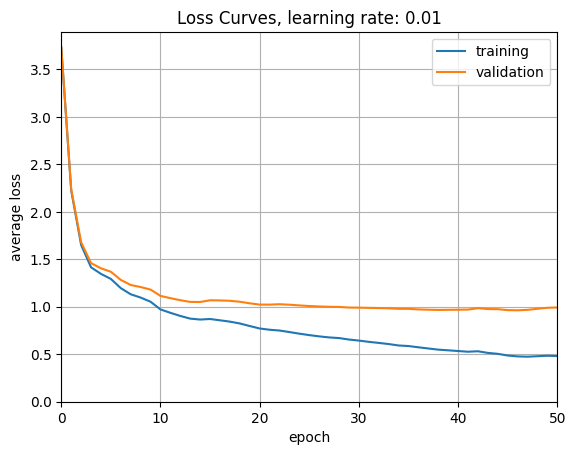

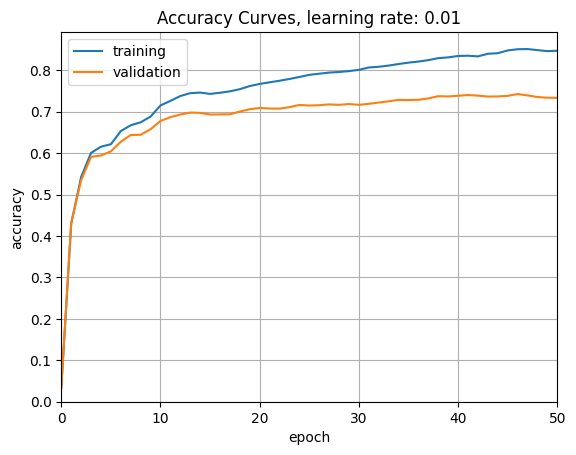

itr: 00   loss: 39304.82   acc: 0.04
itr: 02   loss: 38411.35   acc: 0.06
itr: 04   loss: 37975.25   acc: 0.10
itr: 06   loss: 37518.14   acc: 0.16
itr: 08   loss: 37038.37   acc: 0.21
itr: 10   loss: 36536.83   acc: 0.26
itr: 12   loss: 36007.28   acc: 0.30
itr: 14   loss: 35449.38   acc: 0.33
itr: 16   loss: 34864.72   acc: 0.36
itr: 18   loss: 34253.59   acc: 0.38
itr: 20   loss: 33623.32   acc: 0.40
itr: 22   loss: 32980.40   acc: 0.42
itr: 24   loss: 32327.07   acc: 0.44
itr: 26   loss: 31665.54   acc: 0.45
itr: 28   loss: 31002.34   acc: 0.46
itr: 30   loss: 30344.04   acc: 0.47
itr: 32   loss: 29694.62   acc: 0.48
itr: 34   loss: 29056.96   acc: 0.49
itr: 36   loss: 28433.37   acc: 0.50
itr: 38   loss: 27825.66   acc: 0.51
itr: 40   loss: 27235.23   acc: 0.51
itr: 42   loss: 26663.11   acc: 0.52
itr: 44   loss: 26109.97   acc: 0.53
itr: 46   loss: 25576.17   acc: 0.53
itr: 48   loss: 25061.84   acc: 0.54
Validation accuracy:  0.5269444444444444
Test accuracy:  0.5205555555555555

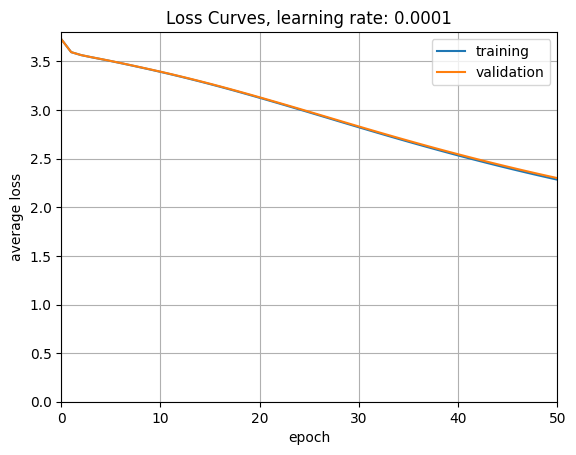

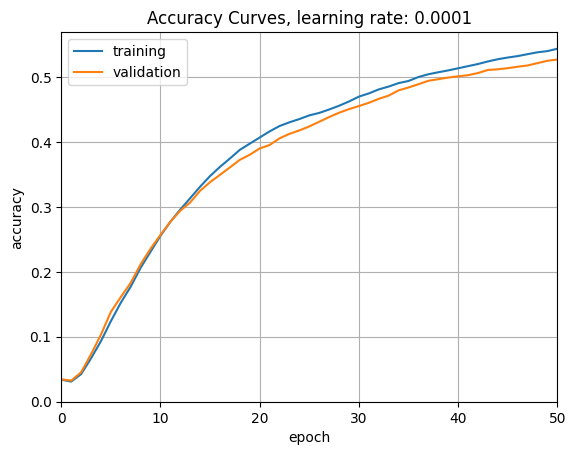

itr: 00   loss: 38089.48   acc: 0.08
itr: 02   loss: 32613.60   acc: 0.37
itr: 04   loss: 26496.65   acc: 0.50
itr: 06   loss: 21990.16   acc: 0.56
itr: 08   loss: 18990.68   acc: 0.60
itr: 10   loss: 16966.98   acc: 0.62
itr: 12   loss: 15540.45   acc: 0.64
itr: 14   loss: 14484.93   acc: 0.66
itr: 16   loss: 13668.65   acc: 0.68
itr: 18   loss: 13013.06   acc: 0.69
itr: 20   loss: 12469.71   acc: 0.70
itr: 22   loss: 12007.60   acc: 0.71
itr: 24   loss: 11606.24   acc: 0.72
itr: 26   loss: 11251.66   acc: 0.73
itr: 28   loss: 10934.01   acc: 0.73
itr: 30   loss: 10646.17   acc: 0.74
itr: 32   loss: 10382.84   acc: 0.75
itr: 34   loss: 10140.00   acc: 0.75
itr: 36   loss: 9914.50   acc: 0.76
itr: 38   loss: 9703.85   acc: 0.76
itr: 40   loss: 9506.08   acc: 0.77
itr: 42   loss: 9319.53   acc: 0.77
itr: 44   loss: 9142.88   acc: 0.78
itr: 46   loss: 8975.01   acc: 0.78
itr: 48   loss: 8814.99   acc: 0.78
Validation accuracy:  0.7372222222222222
Test accuracy:  0.7438888888888889


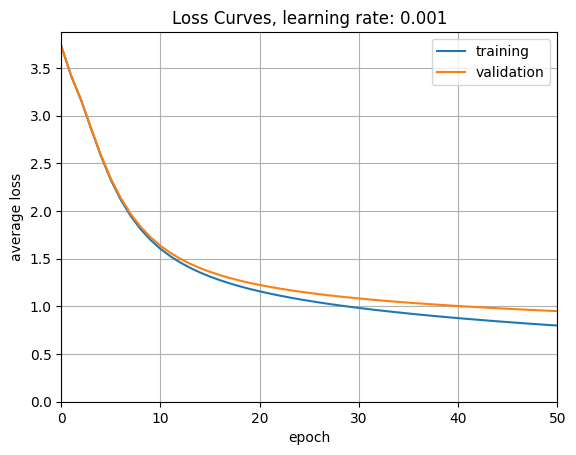

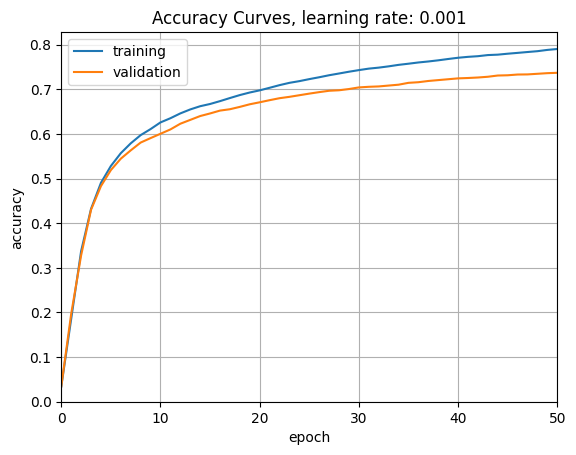

In [22]:
# (1) one with 10 times your tuned learning rate,
train_network(10*learning_rate)

# (2) one with one-tenth your tuned learning rate, and
train_network(learning_rate/10)

# (3) one with your tuned learning rate.
train_network(learning_rate)

---

YOUR ANSWER HERE...

My learning rate of 0.001 has a test accuracy of 0.74 and a training accuracy of 0.78. The curve converges smoothly upwards.

When the learning rate is 10x at 0.01, the accuracy curve is much more bumpy, signalling that the learning rate is too high and causing the optimizer to overshoot and oscillate. The testing accuracy converges a lot faster with a high learning rate and reaches a very high training accuracy of 0.93. However, the actual test accuracy is only marginally better at 0.742. The instability suggests this learning rate is suboptimal despite faster initial convergence.

When the learning rate is 1/10 at 0.0001, the curve is smooth and converges very slowly. In the same amount of iterations it only gets to a training accuracy of 0.54 and a test accuracy of 0.52.

The best network is the tuned learning rate of 0.001 with a final test accuracy of 0.74.

---

## Q3.4 (3 points)

Compute and visualize the confusion matrix of the test data for your best model. Comment on the top few pairs of classes that are most commonly confused.

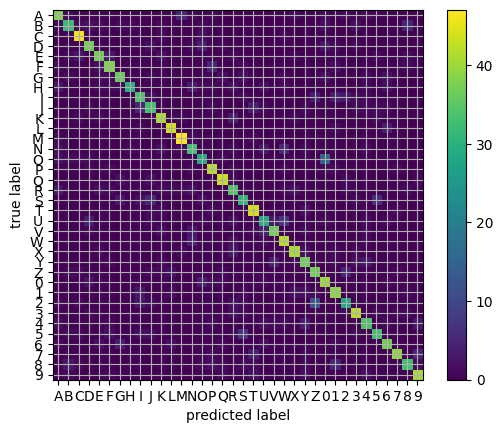

In [23]:
############################## Q 3.4 ##############################
confusion_matrix = np.zeros((train_y.shape[1],train_y.shape[1]))

# compute confusion matrix
##########################
##### your code here #####

# Get predictions on test set
h1 = forward(test_x, params, 'layer1', sigmoid)
test_probs = forward(h1, params, 'output', softmax)

# Get predicted and true labels
pred_labels = np.argmax(test_probs, axis=1)
true_labels = np.argmax(test_y, axis=1)

# Fill confusion matrix
for i in range(len(test_y)):
    confusion_matrix[true_labels[i], pred_labels[i]] += 1

##########################



# visualize confusion matrix
import string
plt.imshow(confusion_matrix,interpolation='nearest')
plt.grid()
plt.xticks(np.arange(36),string.ascii_uppercase[:26] + ''.join([str(_) for _ in range(10)]))
plt.yticks(np.arange(36),string.ascii_uppercase[:26] + ''.join([str(_) for _ in range(10)]))
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.colorbar()
plt.show()

---

YOUR ANSWER HERE...

The top classes that are commonly confused are:
* O - 0
* Z - 2
* 5 - S

These mistakes make sense since they look similar to each other


---

# Q4 Image Compression with Autoencoders

An autoencoder is a neural network that is trained to attempt to copy its input to its output, but it usually allows copying only approximately. This is typically achieved by restricting the number of hidden nodes inside the autoencoder; in other words, the autoencoder would be forced to learn to represent data with this limited number of hidden nodes. This is a useful way of learning compressed representations.

In this section, we will continue using the NIST36 dataset you have from the previous questions.

## Q4.1 Building the Autoencoder

### Q4.1 (4 points)

Due to the difficulty in training auto-encoders, we have to move to the $relu(x) = max(x,0)$ activation function. It is provided for you. We will build an autoencoder with the layers listed below. Initialize the layers with the initialize_weights() function you wrote in Q2.1.2.

- 1024 to 32 dimensions, followed by a ReLU
- 32 to 32 dimensions, followed by a ReLU
- 32 to 32 dimensions, followed by a ReLU
- 32 to 1024 dimensions, followed by a sigmoid (this normalizes the image output for us)

In [24]:
# here we provide the relu activation and its derivative for you
from collections import Counter

def relu(x):
    return np.maximum(x,0)

def relu_deriv(x):
    return (x > 0).astype(float)

############################## Q 4.1 ##############################
params = Counter()

# initialize layers here
##########################
##### your code here #####
initialize_weights(1024, 32, params, 'layer1')
initialize_weights(32, 32, params, 'layer2')
initialize_weights(32, 32, params, 'layer3')
initialize_weights(32, 1024, params, 'output')


##########################



## Q4.2 Training the Autoencoder

### Q4.2.1 (5 points)

To help even more with convergence speed, we will implement momentum. Now, instead of updating $W = W - \alpha \frac{\partial J}{\partial W}$, we will use the update rules $M_W = 0.9 M_W - \alpha \frac{\partial J}{\partial W}$ and $W = W + M_W$. To implement momentum, populate the parameters dictionary with zero-initialized momentum accumulators M, one for each parameter. Then simply perform both update equations for every batch.

### Q4.2.2 (6 points)

Using the provided default settings, train the network for 100 epochs. The loss function that you will use is the total squared error for the output image compared to the input image (they should be the same!). Plot the training loss curve. What do you observe?

itr: 00 	 loss: 874277.00
itr: 02 	 loss: 591034.87
itr: 04 	 loss: 516233.87
itr: 06 	 loss: 471237.31
itr: 08 	 loss: 453115.86
itr: 10 	 loss: 428544.86
itr: 12 	 loss: 421179.06
itr: 14 	 loss: 397293.63
itr: 16 	 loss: 389595.32
itr: 18 	 loss: 386887.91
itr: 20 	 loss: 382540.68
itr: 22 	 loss: 379322.62
itr: 24 	 loss: 372070.66
itr: 26 	 loss: 364884.92
itr: 28 	 loss: 361356.27
itr: 30 	 loss: 359146.22
itr: 32 	 loss: 357278.62
itr: 34 	 loss: 355626.53
itr: 36 	 loss: 354086.56
itr: 38 	 loss: 353510.77
itr: 40 	 loss: 351702.64
itr: 42 	 loss: 349281.15
itr: 44 	 loss: 347790.42
itr: 46 	 loss: 346616.68
itr: 48 	 loss: 345414.74
itr: 50 	 loss: 344422.15
itr: 52 	 loss: 343734.92
itr: 54 	 loss: 343225.60
itr: 56 	 loss: 342588.35
itr: 58 	 loss: 342340.80
itr: 60 	 loss: 341473.69
itr: 62 	 loss: 339925.80
itr: 64 	 loss: 339194.40
itr: 66 	 loss: 338788.22
itr: 68 	 loss: 338314.46
itr: 70 	 loss: 337629.24
itr: 72 	 loss: 337488.33
itr: 74 	 loss: 336944.07
itr: 76 	 lo

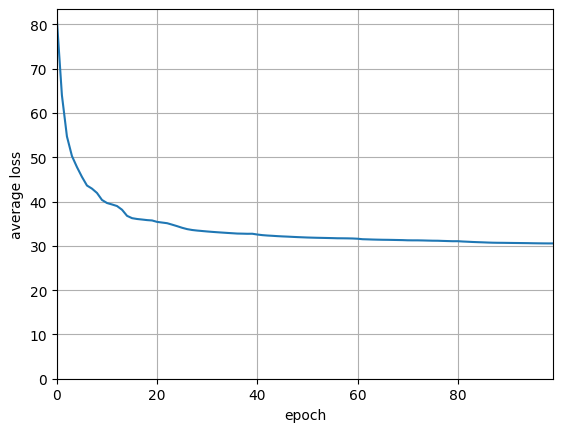

In [25]:
########################### Q 4.2.1 & Q 4.2.2 ########################
# the NIST36 dataset
train_data = scipy.io.loadmat('data/nist36_train.mat')
valid_data = scipy.io.loadmat('data/nist36_valid.mat')

# we don't need labels now!
train_x = train_data['train_data']
valid_x = valid_data['valid_data']

max_iters = 100
# pick a batch size, learning rate
batch_size = 36
learning_rate =  3e-5
hidden_size = 32
lr_rate = 20
batches = get_random_batches(train_x,np.ones((train_x.shape[0],1)),batch_size)
batch_num = len(batches)


# Initialize momentum accumulators (zero-initialized)
layer_names = ['layer1', 'layer2', 'layer3', 'output']
for layer_name in layer_names:
    params['M_W' + layer_name] = np.zeros_like(params['W' + layer_name])
    params['M_b' + layer_name] = np.zeros_like(params['b' + layer_name])

# should look like your previous training loops
losses = []
for itr in range(max_iters):
    total_loss = 0
    for xb,_ in batches:
        # training loop can be exactly the same as q2!
        # your loss is now the total squared error, i.e. the sum of (x-y)^2
        # delta is the d/dx of (x-y)^2
        # to implement momentum
        #   just use 'M_'+name variables as momentum accumulators to keep a saved value over steps
        #   params is a Counter(), which returns a 0 if an element is missing
        #   so you should be able to write your loop without any special conditions

        ##########################
        ##### your code here #####
        
        # Forward pass
        h1 = forward(xb, params, 'layer1', relu)
        h2 = forward(h1, params, 'layer2', relu)
        h3 = forward(h2, params, 'layer3', relu)
        output = forward(h3, params, 'output', sigmoid)
        
        # Compute loss (total squared error)
        loss = np.sum((xb - output) ** 2)
        total_loss += loss
        
        # Backward pass
        # delta is d/dx of (x-y)^2 = 2(y-x) where y=output, x=input
        delta = 2 * (output - xb)
        
        # Backpropagate through all layers
        delta = backwards(delta, params, 'output', sigmoid_deriv)
        delta = backwards(delta, params, 'layer3', relu_deriv)
        delta = backwards(delta, params, 'layer2', relu_deriv)
        backwards(delta, params, 'layer1', relu_deriv)
        
        # Update with momentum: M_W = 0.9 * M_W - alpha * grad_W, then W = W + M_W
        for layer_name in layer_names:
            # Update momentum for weights
            params['M_W' + layer_name] = 0.9 * params['M_W' + layer_name] - learning_rate * params['grad_W' + layer_name]
            params['W' + layer_name] += params['M_W' + layer_name]
            
            # Update momentum for biases
            params['M_b' + layer_name] = 0.9 * params['M_b' + layer_name] - learning_rate * params['grad_b' + layer_name]
            params['b' + layer_name] += params['M_b' + layer_name]
        
        ##########################


    losses.append(total_loss/train_x.shape[0])
    if itr % 2 == 0:
        print("itr: {:02d} \t loss: {:.2f}".format(itr,total_loss))
    if itr % lr_rate == lr_rate-1:
        learning_rate *= 0.9

# plot loss curve
plt.plot(range(len(losses)), losses)
plt.xlabel("epoch")
plt.ylabel("average loss")
plt.xlim(0, len(losses)-1)
plt.ylim(0, None)
plt.grid()
plt.show()

---

YOUR ANSWER HERE...

For the loss curve, I observe a steep drop in the loss within the first 20 epochs and then a gradual decline after that. This suggests that gradient descent is able to quickly converge towards a minimum and then slowly improves thereafter.

---

## Q4.3 Evaluating the Autoencoder

### Q4.3.1 (5 points)

Now let's evaluate how well the autoencoder has been trained. Select 5 classes from the total 36 classes in the validation set and for each selected class show 2 validation images and their reconstruction. What differences do you observe in the reconstructed validation images compared to the original ones?

input shape:  (10, 1024)
reconstructed shape:  (10, 1024)


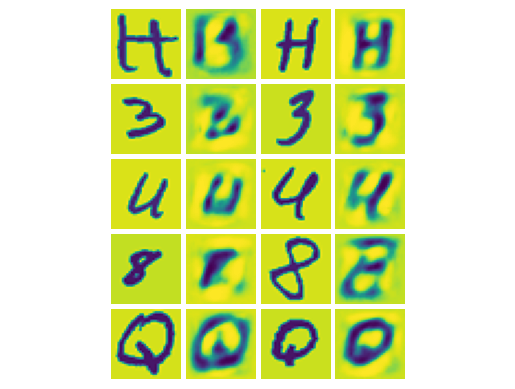

In [26]:
############################## Q 4.3.1 ##############################
# choose 5 classes (change if you want)
visualize_labels = ["H", "3", "U", "8", "Q"]

# get 2 validation images from each label to visualize
visualize_x = np.zeros((2*len(visualize_labels), valid_x.shape[1]))
for i, label in enumerate(visualize_labels):
    idx = 26+int(label) if label.isnumeric() else string.ascii_lowercase.index(label.lower())
    choices = np.random.choice(np.arange(100*idx, 100*(idx+1)), 2, replace=False)
    visualize_x[2*i:2*i+2] = valid_x[choices]

# run visualize_x through your network
# using the forward() function you wrote in Q2.2.1
reconstructed_x = visualize_x
# TODO: name the output reconstructed_x
##########################
##### your code here #####

h1 = forward(visualize_x, params, 'layer1', relu)
h2 = forward(h1, params, 'layer2', relu)
h3 = forward(h2, params, 'layer3', relu)
reconstructed_x = forward(h3, params, 'output', sigmoid)

print("input shape: ", visualize_x.shape)
print("reconstructed shape: ", reconstructed_x.shape)
##########################


# visualize
fig = plt.figure()
plt.axis("off")
grid = ImageGrid(fig, 111, nrows_ncols=(len(visualize_labels), 4), axes_pad=0.05)
for i, ax in enumerate(grid):
    if i % 2 == 0:
        ax.imshow(visualize_x[i//2].reshape((32, 32)).T)
    else:
        ax.imshow(reconstructed_x[i//2].reshape((32, 32)).T)
    ax.set_axis_off()
plt.show()

---

YOUR ANSWER HERE...

When comparing the reconstructed validation images against the original ones, they appear blurry, distorted, and lower resolution. This is because the autoencoder compresses the 1024-dimensional input down to just 32 dimensions in the bottleneck layer, losing fine details in the process. The reconstruction captures the overall shape and structure of the characters but loses sharp edges and precise details.


---

### Q4.3.2 (5 points)

Let’s evaluate the reconstruction quality using Peak Signal-to-noise Ratio (PSNR). PSNR is defined as

$$\text{PSNR} = 20 \times \log_{10}(\text{MAX}_I) - 10\times \log_{10}(\text{MSE})$$

where $\text{MAX}_I$ is the maximum possible pixel value of the image, and $\text{MSE}$ (mean squared error) is computed across all pixels. Said another way, maximum refers to the brightest overall sum (maximum positive value of the sum). You may use skimage.metrics.peak_signal_noise_ratio for convenience. Report the average PSNR you get from the autoencoder across all images in the validation set (it should be around 15).

In [27]:
############################## Q 4.3.2 ##############################
from skimage.metrics import peak_signal_noise_ratio
# evaluate PSNR
##########################
##### your code here #####

PSNR = peak_signal_noise_ratio(visualize_x, reconstructed_x)
print("PSNR: ", PSNR)

##########################



PSNR:  14.74067578295315


---

YOUR ANSWER HERE...

PSNR:  14.592300730410596

This is around 15 which is expected

---

# Q5 (Extra Credit) Extract Text from Images

Run below code to download and put the unzipped data in '/content/images' folder. We have provided you with 01_list.jpg, 02_letters.jpg, 03_haiku.jpg and 04_deep.jpg to test your implementation on.

In [28]:
if not os.path.exists('images'):
  os.mkdir('images')
  !wget http://www.cs.cmu.edu/~lkeselma/16720a_data/images.zip -O images/images.zip
  !unzip "images/images.zip" -d "images"
  os.system("rm images/images.zip")

In [29]:
ls images

01_list.jpg*    02_letters.jpg* 03_haiku.jpg*   04_deep.jpg*


## Q5.1 (Extra Credit) (4 points)

The method outlined above is pretty simplistic, and while it works for the given text samples, it makes several assumptions. What are two big assumptions that the sample method makes?

---

YOUR ANSWER HERE...

The method assumes that:
- The characters are separated and not connected to each other
- The text is in clear horizontal lines

---


## Q5.2 (Extra Credit) (10 points)

Implement the findLetters() function to find letters in the image. Given an RGB image, this function should return bounding boxes for all of the located handwritten characters in the image, as well as a binary black-and-white version of the image im. Each row of the matrix should contain [y1,x1,y2,x2], the positions of the top-left and bottom-right corners of the box. The black-and-white image should be between 0.0 to 1.0, with the characters in white and the background in black (consistent with the images in nist36). Hint: Since we read text left to right, top to bottom, we can use this to cluster the coordinates.

In [30]:
############################## Q 5.2 ##############################
def findLetters(image):
    """
    takes a color image
    returns a list of bounding boxes and black_and_white image
    """
    bboxes = []
    bw = None
    # insert processing in here
    # one idea estimate noise -> denoise -> greyscale -> threshold -> morphology -> label -> skip small boxes
    # this can be 10 to 15 lines of code using skimage functions

    ##########################
    ##### your code here #####
        
    # Convert to grayscale
    gray = skimage.color.rgb2gray(image)

    # Denoise (blur to reduce noise)
    denoised = skimage.filters.gaussian(gray, sigma=1)

    # Threshold to binary
    thresh = skimage.filters.threshold_otsu(denoised)
    binary = denoised < thresh

    # Morphological operations to close gaps
    cleaned = skimage.morphology.closing(binary, skimage.morphology.disk(1))
    
    # Label connected components
    labeled = skimage.measure.label(cleaned)

    # Extract bounding boxes
    regions = skimage.measure.regionprops(labeled)

    for region in regions:
        if region.area < 100:
            continue

        minr, minc, maxr, maxc = region.bbox
        bboxes.append([minr, minc, maxr, maxc])

    # Create black-and-white image
    bw = cleaned.astype(float)
        

    ##########################


    return bboxes, bw

## Q5.3 (Extra Credit) (3 points)

Using the provided code below, visualize all of the located boxes on top of the binary image to show the accuracy of your findLetters() function. Include all the provided sample images with the boxes.


01_list.jpg


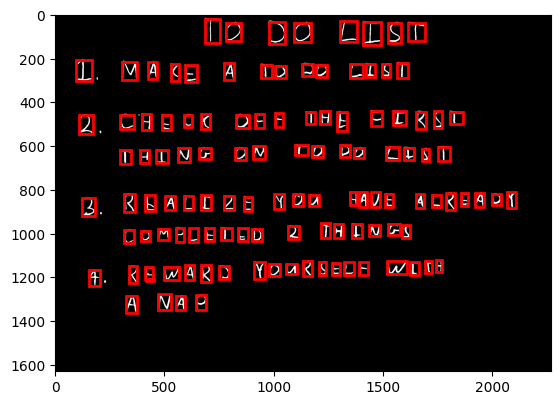


02_letters.jpg


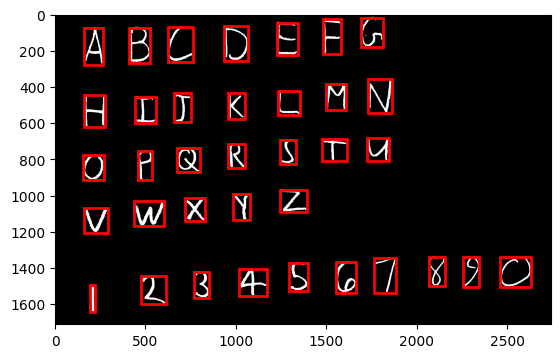


03_haiku.jpg


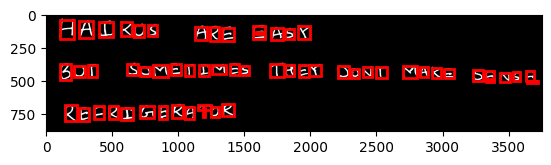


04_deep.jpg


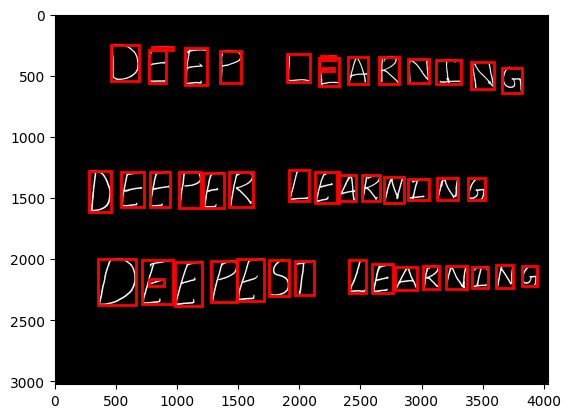

In [31]:
############################## Q 5.3 ##############################
# do not include any more libraries here!
# no opencv, no sklearn, etc!
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

for imgno, img in enumerate(sorted(os.listdir('images'))):
    im1 = skimage.img_as_float(skimage.io.imread(os.path.join('images',img)))
    bboxes, bw = findLetters(im1)

    print('\n' + img)
    plt.imshow(1-bw, cmap="Greys") # reverse the colors of the characters and the background for better visualization
    for bbox in bboxes:
        minr, minc, maxr, maxc = bbox
        rect = matplotlib.patches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)
    plt.show()

## Q5.4 (Extra Credit) (8 points)

You will now load the image, find the character locations, classify each one with the network you trained in Q3.1, and return the text contained in the image. Be sure you try to make your detected images look like the images from the training set. Visualize them and act accordingly. If you find that your classifier performs poorly, consider dilation under skimage morphology to make the letters thicker.

Your solution is correct if you can correctly detect most of the letters and classify approximately 70\% of the letters in each of the sample images.

Run your code on all the provided sample images in '/content/images'. Show the extracted text. It is fine if your code ignores spaces, but if so, please provide a written answer with manually added spaces.


01_list.jpg
Detected text: T0D0LI5TIMAXEAT0Q0LISTICH2EK0FFTH1FIR5TTHING0NT0D0LIST3R8ALIZEY0UHAVEALR2ADTC0MPLET2D2THINGS488WARDY0URSELFWITR4ANAP


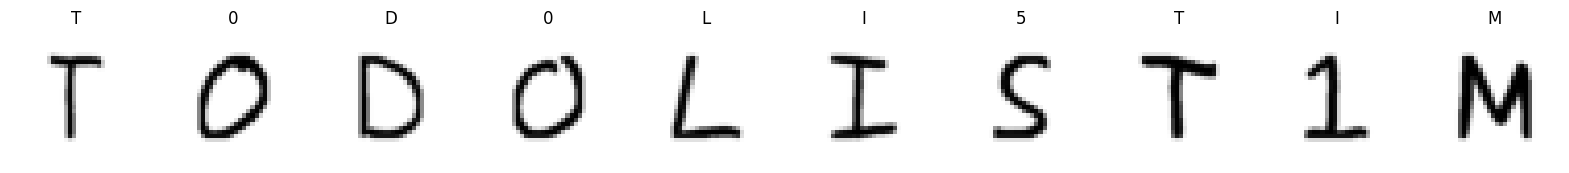


02_letters.jpg
Detected text: FG1ECDENMHIJKL5TUXPQ0ZYWXV71Y0S63FZ1

03_haiku.jpg
Detected text: HAIKUSA8EEASX4BUTS0METIMESTREXDONTMAK2SQNSF44REFRIGERAM10R

04_deep.jpg
Detected text: DC45YLLMATYIUH4D55T5YL5A8YINGD55T5ST1EA8NINGM


In [50]:
############################## Q 5.4 ##############################
for imgno, img in enumerate(sorted(os.listdir('images'))):
    im1 = skimage.img_as_float(skimage.io.imread(os.path.join('images',img)))
    bboxes, bw = findLetters(im1)
    print('\n' + img)

    # find the rows using clustering by y-coordinate
    ##########################
    ##### your code here #####
    
    # Sort bboxes by y-coordinate (top to bottom), then x-coordinate (left to right)
    bboxes = sorted(bboxes, key=lambda x: (x[0], x[1]))
    
    # Group into rows based on vertical overlap
    rows = []
    current_row = []
    row_y_threshold = 20  # pixels - adjust if needed
    
    for bbox in bboxes:
        minr, minc, maxr, maxc = bbox
        if len(current_row) == 0:
            current_row.append(bbox)
        else:
            # Check if bbox is in same row (similar y-coordinate)
            last_bbox = current_row[-1]
            if abs(minr - last_bbox[0]) < row_y_threshold:
                current_row.append(bbox)
            else:
                # Start new row
                rows.append(sorted(current_row, key=lambda x: x[1]))  # sort by x
                current_row = [bbox]
    
    if current_row:
        rows.append(sorted(current_row, key=lambda x: x[1]))
    
    ##########################

    # crop the bounding boxes
    # note.. before you flatten, transpose the image (that's how the dataset is!)
    # consider doing a square crop, and even using np.pad() to get your images looking more like the dataset
    ##########################
    ##### your code here #####
    
    cropped_chars = []
    for row in rows:
        for bbox in row:
            minr, minc, maxr, maxc = bbox
            
            # Extract the character
            char_img = bw[minr:maxr, minc:maxc]
            
            # CRITICAL: Check if we need to invert (training data has WHITE on BLACK)
            if np.mean(char_img) > 0.5:
                char_img = 1 - char_img
            
            # FILL hollow characters using morphological closing
            char_img = skimage.morphology.closing(char_img, skimage.morphology.disk(2))
            
            # Dilate to make characters thicker (more like training data)
            char_img = skimage.morphology.dilation(char_img, skimage.morphology.disk(3))
            
            # Make it square by padding with zeros (black background)
            height, width = char_img.shape
            max_dim = max(height, width)
            
            # Add some extra padding (like the training data)
            pad_size = int(max_dim * 0.3)  # 30% padding
            max_dim += 2 * pad_size
            
            pad_h = (max_dim - height) // 2
            pad_w = (max_dim - width) // 2
            
            char_img = np.pad(char_img, 
                            ((pad_h, max_dim - height - pad_h),
                             (pad_w, max_dim - width - pad_w)),
                            mode='constant', constant_values=0)
            
            # Resize to 32x32
            char_img = skimage.transform.resize(char_img, (32, 32), 
                                                anti_aliasing=True)
            
            # Normalize to [0, 1] range
            if char_img.max() > 0:
                char_img = char_img / char_img.max()

            # Invert colors (black on white)
            char_img = 1 - char_img
            
            # Transpose THEN flatten 
            char_img = char_img.T.flatten()
            
            cropped_chars.append(char_img)
    
    ##########################

    # load the weights
    # run the crops through your neural network and print them out
    import pickle
    import string
    letters = np.array([_ for _ in string.ascii_uppercase[:26]] + [str(_) for _ in range(10)])
    params = pickle.load(open('q3_weights.pickle','rb'))
    ##########################
    ##### your code here #####
    
    if len(cropped_chars) > 0:
        # Stack all characters into a batch
        X = np.array(cropped_chars)
        
        # Forward pass through network
        h1 = forward(X, params, 'layer1', sigmoid)
        probs = forward(h1, params, 'output', softmax)
        
        # Get predictions
        predictions = np.argmax(probs, axis=1)
        
        # Convert to letters
        predicted_text = ''.join([letters[pred] for pred in predictions])
        print("Detected text:", predicted_text)
        
        # Optional: visualize first few to debug
        if imgno == 0:  # Only for first image
            fig, axes = plt.subplots(1, min(10, len(cropped_chars)), figsize=(20, 3))
            if len(cropped_chars) == 1:
                axes = [axes]
            for i in range(min(10, len(cropped_chars))):
                axes[i].imshow(cropped_chars[i].reshape(32, 32).T, cmap='gray')
                axes[i].set_title(f'{letters[predictions[i]]}')
                axes[i].axis('off')
            plt.show()
    else:
        print("No characters detected")
    
    ##########################

In [34]:
letters

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
       '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U1')

class_0_idx 0
letter[class_0_idx] A


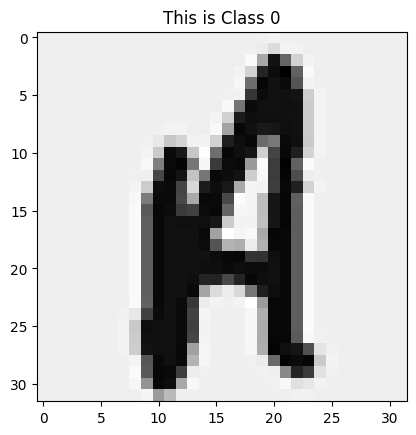

In [38]:
# Run this to check the Truth
import matplotlib.pyplot as plt

# Find the first example of Class 0
class_0_idx = np.argmax(train_y[:, 0]) 
print("class_0_idx", class_0_idx)
print("letter[class_0_idx]", letters[class_0_idx])
plt.imshow(train_x[class_0_idx].reshape(32,32).T, cmap='gray')
plt.title("This is Class 0")
plt.show()

---

YOUR ANSWER HERE... (if your code ignores spaces)

---

01_list.jpg
Detected text: T0D0LI5TIMAXEAT0Q0LISTICH2EK0FFTH1FIR5TTHING0NT0D0LIST3R8ALIZEY0UHAVEALR2ADTC0MPLET2D2THINGS488WARDY0URSELFWITR4ANAP

T0D0 LI5T 
I MAXE A T0Q0 LIST 
I CH2EK 0FF TH1 FIR5T THING 0N T0D0 LIST 
3 R8ALIZE Y0U HAVE ALR2ADT C0MPLET2D 2 THINGS
4 88WARD Y0URSELF WITR4 A NAP

---

02_letters.jpg
Detected text: FG1ECDENMHIJKL5TUXPQ0ZYWXV71Y0S63FZ1

F G 1 E C D E N M H I J K L 5 T U X P Q 0 Z Y W X V 7 1 Y 0 S 6 3 F Z 1

---

03_haiku.jpg
Detected text: HAIKUSA8EEASX4BUTS0METIMESTREXDONTMAK2SQNSF44REFRIGERAM10R

HAIKUS A8E EASX4
BUT S0METIMES TREX DONT MAK2 SQNSF44
REFRIGERAM10R

---

04_deep.jpg
Detected text: DC45YLLMATYIUH4D55T5YL5A8YINGD55T5ST1EA8NINGM

DC45 YLLMATYIUH4
D55T5Y L5A8YING
D55T5ST 1EA8NINGM

---